In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('gurgaon_data_v2.csv')
df.head()

,property_type,society,sector,price,price_sq.feet,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,bptp astaire gardens,sector 70a,1.20,7058.0,1700.0,Super Built up area 1700(157.94 sq.m.)Built Up...,3,3,3+,not available,2.0,NaN,1 to 5 Year Old,"['Sector 54 Chowk Metro Station', 'Airia Mall'...","['5 Fan', '1 Exhaust Fan', '1 Dining Table', '...","['Intercom Facility', 'Lift(s)', 'Swimming Poo..."
1,house,independent,sector 56,7.50,23148.0,3240.0,Plot area 360(301.01 sq.m.),8,8,3+,"pooja room,study room,servant room",3.0,North-East,1 to 5 Year Old,"['Sector metro station', 'Sector metro station...","['1 Water Purifier', '25 Fan', '1 Fridge', '1 ...","['Feng Shui / Vaastu Compliant', 'Private Gard..."
2,flat,vatika lifestyle homes,sector 83,1.15,8214.0,1400.0,Super Built up area 1832(170.2 sq.m.)Carpet ar...,3,3,1,not available,7.0,South-West,5 to 10 Year Old,"['Sapphire 83 Mall', 'NH – 08', 'Knowledge Tre...","['3 Wardrobe', '2 Fan', '1 Exhaust Fan', '2 Ge...","['Security / Fire Alarm', 'Feng Shui / Vaastu ..."
3,house,independent,sector 11,2.10,17284.0,1215.0,Plot area 135(112.88 sq.m.),6,6,3+,not available,3.0,NaN,1 to 5 Year Old,"['Rajiv Chowk Mosque', 'Rachna Dental Clinic',...","['3 Chimney', 'No AC', 'No Bed', 'No Curtains'...","['Water Storage', 'Visitor Parking', 'Waste Di..."
4,flat,emaar gurgaon greens,sector 102,1.40,8484.0,1650.0,Super Built up area 1650(153.29 sq.m.)Built Up...,3,3,3,servant room,10.0,East,1 to 5 Year Old,"['JMS Marine Square Mall', 'Dwarka Expressway'...","['3 AC', 'No Bed', 'No Chimney', 'No Curtains'...","['Power Back-up', 'Intercom Facility', 'Lift(s..."


### areaWithType

In [4]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
3119,1.76,1776.0,Super Built up area 1776(165 sq.m.)Built Up ar...
2026,1.68,1976.0,Super Built up area 1976(183.58 sq.m.)Built Up...
861,2.00,1380.0,Carpet area: 1380 (128.21 sq.m.)
325,1.38,1023.0,Super Built up area 1650(153.29 sq.m.)Carpet a...
963,0.72,990.0,Carpet area: 990 (91.97 sq.m.)


- So we have plot area, builtup area and super built up area. some in sq.m., some in sq.feet and we also have area column( in sq. feet). Lets do it one by one

In [5]:
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [6]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [7]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [8]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [9]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
16,0.70,flat,1352.0,Carpet area: 1352 (125.6 sq.m.),NaN,NaN,1352.0
3410,5.90,flat,3375.0,Super Built up area 3363(312.43 sq.m.),3363.0,NaN,NaN
2863,1.15,flat,1000.0,Super Built up area 1450(134.71 sq.m.)Built Up...,1450.0,1400.0,1000.0
3577,4.70,flat,2380.0,Super Built up area 2380(221.11 sq.m.)Carpet a...,2380.0,NaN,1231.0
2936,1.60,house,100.0,Plot area 100(9.29 sq.m.),NaN,NaN,NaN


In [10]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,7.5,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN
3,2.1,house,1215.0,Plot area 135(112.88 sq.m.),NaN,NaN,NaN
8,5.6,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
10,9.0,house,4235.0,Plot area 5605(520.72 sq.m.)Built Up area: 520...,NaN,5200.0,4235.0
12,12.0,house,3078.0,Plot area 342(285.96 sq.m.),NaN,NaN,NaN


In [11]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [12]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,7.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN
3,2.10,house,1215.0,Plot area 135(112.88 sq.m.),NaN,NaN,NaN
8,5.60,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
12,12.00,house,3078.0,Plot area 342(285.96 sq.m.),NaN,NaN,NaN
13,1.50,house,1170.0,Plot area 130(108.7 sq.m.),NaN,NaN,NaN
14,5.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,NaN,NaN
17,9.40,house,3600.0,Plot area 400(334.45 sq.m.),NaN,NaN,NaN
30,15.00,house,4500.0,Plot area 500(418.06 sq.m.),NaN,NaN,NaN
31,27.50,house,11286.0,Plot area 1254(1048.5 sq.m.),NaN,NaN,NaN
33,7.25,house,360.0,Plot area 360(33.45 sq.m.),NaN,NaN,NaN


* As we can see, in case of `Plot Area` all other are nan. So lets fix this.

In [13]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [14]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [15]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

* Still its in sq.m. We need sq. ft.

In [16]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']


In [17]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [18]:
all_nan_df.head(10)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,7.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.0,NaN
3,2.10,house,1215.0,Plot area 135(112.88 sq.m.),NaN,1215.0,NaN
8,5.60,house,2700.0,Plot area 300(250.84 sq.m.),NaN,2700.0,NaN
12,12.00,house,3078.0,Plot area 342(285.96 sq.m.),NaN,3078.0,NaN
13,1.50,house,1170.0,Plot area 130(108.7 sq.m.),NaN,1170.0,NaN
14,5.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,1800.0,NaN
17,9.40,house,3600.0,Plot area 400(334.45 sq.m.),NaN,3600.0,NaN
30,15.00,house,4500.0,Plot area 500(418.06 sq.m.),NaN,4500.0,NaN
31,27.50,house,11286.0,Plot area 1254(1048.5 sq.m.),NaN,11286.0,NaN
33,7.25,house,360.0,Plot area 360(33.45 sq.m.),NaN,360.0,NaN


In [19]:
# update the original df
df.update(all_nan_df)

In [20]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_sq.feet             0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1171
agePossession             1
nearbyLocations         206
furnishDetails         1026
features                705
super_built_up_area    2007
built_up_area          2112
carpet_area            1941
dtype: int64

### additionalRoom

In [21]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1683
servant room                                      709
study room                                        250
others                                            237
pooja room                                        170
store room                                        107
study room,servant room                            99
pooja room,servant room                            84
pooja room,study room,servant room,store room      71
servant room,others                                60
pooja room,study room,servant room                 56
pooja room,study room,servant room,others          54
servant room,pooja room                            38
servant room,store room                            31
study room,others                                  30
pooja room,study room                              24
pooja room,store room                              17
pooja room,others                                  17
servant room,

`'study room', 'servant room', 'store room', 'pooja room', 'others'` These are the major categories.

In [22]:
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [23]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
791,study room,1,0,0,0,0
633,"store room,pooja room,study room",1,0,1,1,0
704,"pooja room,servant room",0,1,0,1,0
716,servant room,0,1,0,0,0
1792,servant room,0,1,0,0,0


### agePossession

In [24]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1698
5 to 10 Year Old       604
0 to 1 Year Old        548
undefined              357
10+ Year Old           351
Under Construction      91
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Oct 2024                 8
Jan 2024                 8
Dec 2025                 7
Aug 2023                 7
Jun 2024                 7
Nov 2023                 5
Aug 2024                 5
Sep 2023                 4
Jul 2024                 4
By 2025                  4
Oct 2023                 4
Jan 2025                 4
May 2024                 3
Feb 2024                 3
Nov 2024                 3
Sep 2025                 2
Mar 2025                 2
Oct 2025                 2
Dec 2026                 2
Jul 2027                 2
Jul 2025                 2
Jun 2027                 2
Aug 2025                 2
By 2027       

In [26]:
def categorize_agePossession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value:
        return "Under Construction"

    year_match = re.search(r'20\d{2}', value)
    
    if year_match:
        year = int(year_match.group())
        
        if year > 2025:
            return "Under Construction"
        elif year == 2025 or year == 2024:
            return "New Property"
        elif year == 2023:
            return "Relatively New"
        else:
            return "Undefined"

    return "Undefined"

    

In [27]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [28]:
df['agePossession'].value_counts()

agePossession
Relatively New        1759
New Property           760
Moderately Old         604
Undefined              358
Old Property           351
Under Construction     109
Name: count, dtype: int64

### furnishDetails

In [30]:
df.head(5)[['furnishDetails', 'features']]

,furnishDetails,features
0,"['5 Fan', '1 Exhaust Fan', '1 Dining Table', '...","['Intercom Facility', 'Lift(s)', 'Swimming Poo..."
1,"['1 Water Purifier', '25 Fan', '1 Fridge', '1 ...","['Feng Shui / Vaastu Compliant', 'Private Gard..."
2,"['3 Wardrobe', '2 Fan', '1 Exhaust Fan', '2 Ge...","['Security / Fire Alarm', 'Feng Shui / Vaastu ..."
3,"['3 Chimney', 'No AC', 'No Bed', 'No Curtains'...","['Water Storage', 'Visitor Parking', 'Waste Di..."
4,"['3 AC', 'No Bed', 'No Chimney', 'No Curtains'...","['Power Back-up', 'Intercom Facility', 'Lift(s..."


In [32]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(rf"(\d+)\s+{re.escape(furnishing)}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [33]:
furnishings_df.shape

(3941, 19)

In [34]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\kumar\AppData\Local\Temp\ipykernel_12116\114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [35]:
furnishings_df.head()

,Light,Geyser,Washing Machine,AC,Microwave,Water Purifier,TV,Modular Kitchen,Fan,Chimney,Dining Table,Curtains,Bed,Exhaust Fan,Sofa,Wardrobe,Fridge,Stove
0,10,2,0,5,0,0,0,1,5,1,1,1,3,1,1,3,0,1
1,78,16,0,9,0,1,0,1,25,3,1,16,0,1,0,28,1,1
2,5,2,0,0,0,0,0,1,2,0,0,1,0,1,0,3,0,0
3,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0
4,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0


#### Since this many colums will slow down the model for no good reason, it shall be optimized.One way is to cluster them since we dont know what categories are more important.

In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [37]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [38]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

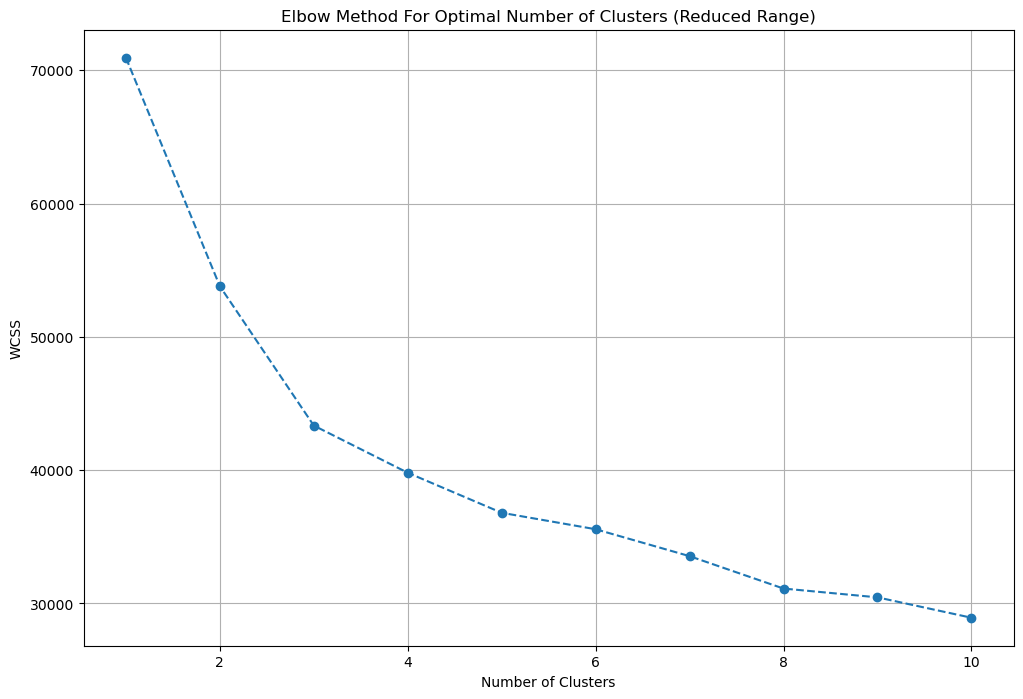

In [39]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

* Generally we make that many clusters for which slope starts to become less sharp. In our case it will be 3. So unfurnished, semifurnished, furnished.

In [40]:
n_cluster = 3
kmeans = KMeans(n_clusters= n_cluster, random_state=42)
kmeans.fit(scaled_data)

cluster_assign = kmeans.predict(scaled_data)

In [41]:
df.head()

,property_type,society,sector,price,price_sq.feet,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,Light,Geyser,Washing Machine,AC,Microwave,Water Purifier,TV,Modular Kitchen,Fan,Chimney,Dining Table,Curtains,Bed,Exhaust Fan,Sofa,Wardrobe,Fridge,Stove
0,flat,bptp astaire gardens,sector 70a,1.20,7058.0,1700.0,Super Built up area 1700(157.94 sq.m.)Built Up...,3,3,3+,not available,2.0,NaN,Relatively New,"['Sector 54 Chowk Metro Station', 'Airia Mall'...","['5 Fan', '1 Exhaust Fan', '1 Dining Table', '...","['Intercom Facility', 'Lift(s)', 'Swimming Poo...",1700.0,1450.0,NaN,0,0,0,0,0,10,2,0,5,0,0,0,1,5,1,1,1,3,1,1,3,0,1
1,house,independent,sector 56,7.50,23148.0,3240.0,Plot area 360(301.01 sq.m.),8,8,3+,"pooja room,study room,servant room",3.0,North-East,Relatively New,"['Sector metro station', 'Sector metro station...","['1 Water Purifier', '25 Fan', '1 Fridge', '1 ...","['Feng Shui / Vaastu Compliant', 'Private Gard...",NaN,3240.0,NaN,1,1,0,1,0,78,16,0,9,0,1,0,1,25,3,1,16,0,1,0,28,1,1
2,flat,vatika lifestyle homes,sector 83,1.15,8214.0,1400.0,Super Built up area 1832(170.2 sq.m.)Carpet ar...,3,3,1,not available,7.0,South-West,Moderately Old,"['Sapphire 83 Mall', 'NH – 08', 'Knowledge Tre...","['3 Wardrobe', '2 Fan', '1 Exhaust Fan', '2 Ge...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1832.0,NaN,1400.00,0,0,0,0,0,5,2,0,0,0,0,0,1,2,0,0,1,0,1,0,3,0,0
3,house,independent,sector 11,2.10,17284.0,1215.0,Plot area 135(112.88 sq.m.),6,6,3+,not available,3.0,NaN,Relatively New,"['Rajiv Chowk Mosque', 'Rachna Dental Clinic',...","['3 Chimney', 'No AC', 'No Bed', 'No Curtains'...","['Water Storage', 'Visitor Parking', 'Waste Di...",NaN,1215.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0
4,flat,emaar gurgaon greens,sector 102,1.40,8484.0,1650.0,Super Built up area 1650(153.29 sq.m.)Built Up...,3,3,3,servant room,10.0,East,Relatively New,"['JMS Marine Square Mall', 'Dwarka Expressway'...","['3 AC', 'No Bed', 'No Chimney', 'No Curtains'...","['Power Back-up', 'Intercom Facility', 'Lift(s...",1650.0,1300.0,1022.58,0,1,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0


* Now we no longer need those extra columns i.e. last 18 columns

In [42]:
df = df.iloc[:,:-18]

In [44]:
df['furnishing_type'] = cluster_assign

In [54]:
df.head(5)[['furnishDetails','furnishing_type']]

,furnishDetails,furnishing_type
0,"['5 Fan', '1 Exhaust Fan', '1 Dining Table', '2 Geyser', '1 Stove', '10 Light', '5 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', '3 Bed', '3 Wardrobe', '1 Sofa', 'No Microwave', 'No Fridge', 'No TV', 'No Washing Machine', 'No Water Purifier']",0
1,"['1 Water Purifier', '25 Fan', '1 Fridge', '1 Exhaust Fan', '1 Dining Table', '16 Geyser', '1 Stove', '78 Light', '9 AC', '3 Chimney', '16 Curtains', '1 Modular Kitchen', '28 Wardrobe', 'No Bed', 'No Microwave', 'No Sofa', 'No TV', 'No Washing Machine']",0
2,"['3 Wardrobe', '2 Fan', '1 Exhaust Fan', '2 Geyser', '5 Light', '1 Modular Kitchen', '1 Curtains', 'No AC', 'No Bed', 'No Chimney', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",2
3,"['3 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",1
4,"['3 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",1


In [4]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [53]:
df.sample(20)[['furnishDetails','furnishing_type']]

,furnishDetails,furnishing_type
1873,[],1
2098,[],1
1501,"['1 Water Purifier', '15 Fan', '1 Fridge', '1 Exhaust Fan', '1 Dining Table', '8 Geyser', '1 Stove', '20 Light', '3 AC', '1 TV', '1 Chimney', '1 Curtains', '3 Bed', '2 Wardrobe', '1 Sofa', '1 Washing Machine', '1 Microwave', 'No Modular Kitchen']",0
1089,NaN,1
3694,"['1 Water Purifier', '5 Fan', '1 Fridge', '1 Exhaust Fan', '1 Dining Table', '1 Geyser', '1 Stove', '12 Light', '5 AC', '1 Chimney', '4 Curtains', '1 Modular Kitchen', '1 TV', '3 Wardrobe', '1 Sofa', '1 Microwave', 'No Bed', 'No Washing Machine']",0
1685,[],1
85,"['7 Fan', '1 Exhaust Fan', '2 Geyser', '14 Light', '5 AC', '1 Chimney', '1 Modular Kitchen', '3 Wardrobe', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",2
1229,"['3 Fan', '1 Exhaust Fan', '1 Geyser', '11 Light', '1 Chimney', '1 Curtains', '1 Modular Kitchen', '2 Wardrobe', 'No AC', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",2
701,NaN,1
3855,"['5 Wardrobe', '10 Fan', '1 Exhaust Fan', '5 Geyser', '15 Light', '1 Chimney', '1 Modular Kitchen', '1 Curtains', '5 AC', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",2


#### After checking many times, its obvious that it assignes 0 to furnished, 2 to semi furnished and 1 to unfurnished. i want to change it like 0 to unfurnished, 1 to semi furnished, 2 to furnished.

In [56]:
mapping = {
    1: 0,  # unfurnished → 0
    2: 1,  # semi → 1
    0: 2   # furnished → 2
}

df['furnishing_type'] = df['furnishing_type'].map(mapping)

In [57]:
df.to_csv("to_be_continue.csv", index = False)

### Features

In [3]:
df = pd.read_csv('to_be_continue.csv')
df.head()

,property_type,society,sector,price,price_sq.feet,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type
0,flat,bptp astaire gardens,sector 70a,1.20,7058.0,1700.0,Super Built up area 1700(157.94 sq.m.)Built Up...,3,3,3+,not available,2.0,NaN,Relatively New,"['Sector 54 Chowk Metro Station', 'Airia Mall'...","['5 Fan', '1 Exhaust Fan', '1 Dining Table', '...","['Intercom Facility', 'Lift(s)', 'Swimming Poo...",1700.0,1450.0,NaN,0,0,0,0,0,2
1,house,independent,sector 56,7.50,23148.0,3240.0,Plot area 360(301.01 sq.m.),8,8,3+,"pooja room,study room,servant room",3.0,North-East,Relatively New,"['Sector metro station', 'Sector metro station...","['1 Water Purifier', '25 Fan', '1 Fridge', '1 ...","['Feng Shui / Vaastu Compliant', 'Private Gard...",NaN,3240.0,NaN,1,1,0,1,0,2
2,flat,vatika lifestyle homes,sector 83,1.15,8214.0,1400.0,Super Built up area 1832(170.2 sq.m.)Carpet ar...,3,3,1,not available,7.0,South-West,Moderately Old,"['Sapphire 83 Mall', 'NH – 08', 'Knowledge Tre...","['3 Wardrobe', '2 Fan', '1 Exhaust Fan', '2 Ge...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1832.0,NaN,1400.00,0,0,0,0,0,1
3,house,independent,sector 11,2.10,17284.0,1215.0,Plot area 135(112.88 sq.m.),6,6,3+,not available,3.0,NaN,Relatively New,"['Rajiv Chowk Mosque', 'Rachna Dental Clinic',...","['3 Chimney', 'No AC', 'No Bed', 'No Curtains'...","['Water Storage', 'Visitor Parking', 'Waste Di...",NaN,1215.0,NaN,0,0,0,0,0,0
4,flat,emaar gurgaon greens,sector 102,1.40,8484.0,1650.0,Super Built up area 1650(153.29 sq.m.)Built Up...,3,3,3,servant room,10.0,East,Relatively New,"['JMS Marine Square Mall', 'Dwarka Expressway'...","['3 AC', 'No Bed', 'No Chimney', 'No Curtains'...","['Power Back-up', 'Intercom Facility', 'Lift(s...",1650.0,1300.0,1022.58,0,1,0,0,0,0


In [6]:
df[['society', 'features']].sample(5)

,society,features
3838,international city by sobha phase 2,"['Private Garden / Terrace', 'Maintenance Staff', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Fitness Centre / GYM', 'Waste Disposal', 'Club house / Community Center']"
2146,hsiidc sidco aravali,"['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'Recently Renovated', 'Piped-gas', 'Visitor Parking', 'Park', 'Security Personnel', 'Natural Light', 'Waste Disposal']"
960,sector 38 rwa,"['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Waste Disposal', 'Rain Water Harvesting']"
1363,samaspurkunj,"['Security / Fire Alarm', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Internet/wi-fi connectivity']"
406,vipul tatvam villa,"['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking', 'Waste Disposal', 'Rain Water Harvesting']"


In [7]:
df['features'].isnull().sum()

np.int64(705)

In [8]:
app_df = pd.read_csv('archive/apartments.csv')
app_df.head(3)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"
2,Adani Brahma Samsara Vilasa,"Land, 3, 4 BHK Independent Floor in Sector 63, Gurgaon","['AIPL Business Club Sector 62', 'Heritage Xperiential Learning School', 'CK Birla Hospital', 'Paras Trinity Mall Sector 63', 'Rapid Metro Station Sector 56']","{'AIPL Business Club Sector 62': '2.7 Km', 'Heritage Xperiential Learning School': '2 Km', 'CK Birla Hospital': '2.5 Km', 'Paras Trinity Mall Sector 63': '3.5 Km', 'Rapid Metro Station Sector 56': '3.8 Km', 'De Adventure Park': '6.8 Km', 'Golf Course Ext Rd': '99 Meter', 'DoubleTree by Hilton Hotel Gurgaon': '3.6 Km', 'KIIT College of Engineering Sohna Road': '8.4 Km', 'Mehrauli-Gurgaon Road': '11.8 Km', 'Indira Gandhi International Airport': '21.1 Km', 'Nirvana Rd': '160 Meter', 'TERI Golf Course': '8.7 Km'}",https://www.99acres.com/adani-brahma-samsara-vilasa-sector-63-gurgaon-npxid-r327995,"{'3 BHK': {'building_type': 'Independent Floor', 'area_type': 'Super Built-up Area', 'area': '1,800 - 3,150 sq.ft.', 'price-range': '₹ 2.43 - 15.75 Cr'}, '4 BHK': {'building_type': 'Independent Floor', 'area_type': 'Super Built-up Area', 'area': '2,750 - 4,500 sq.ft.', 'price-range': '₹ 3.36 - 22.5 Cr'}, 'Land': {'building_type': '', 'area_type': 'Plot Area', 'area': '500 - 4,329 sq.ft.', 'price-range': '₹ 2.05 - 41.13 Cr'}}","['Terrace Garden', 'Gazebo', 'Fountain', 'Amphitheatre', 'Party Lawn', 'Basketball Court', 'Badminton Court', 'Yoga/Meditation Area', 'Indoor Games']"


In [9]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [10]:
temp_df = df[df['features'].isnull()]

In [11]:
temp_df.shape

(705, 26)

In [12]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [13]:
df.loc[temp_df.index, 'features'] = x.values

In [14]:
df['features'].isnull().sum()

np.int64(549)

* Now since we have no more data, we need to do use KMeans again.

In [15]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

* Firstly we need to convert string rep in Features column to actual lists

In [17]:
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [18]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
674,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0
3308,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2161,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0
3375,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3309,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0


In [19]:
features_binary_df.shape

(3941, 130)

In [22]:
wcss_reduced = []
for i in range(1,11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

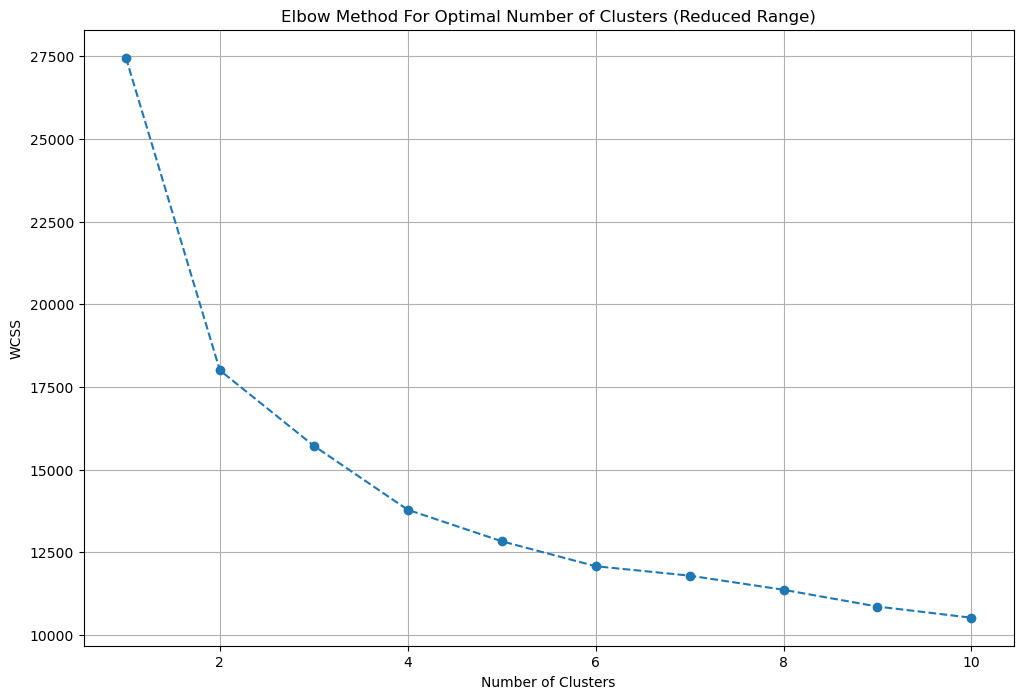

In [24]:
plt.figure(figsize = (12,8))
plt.plot(range(1,11), wcss_reduced, marker = 'o', linestyle = '--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [25]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [26]:
df['luxury_score'] = luxury_score

In [27]:
df.head(3)

,property_type,society,sector,price,price_sq.feet,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,flat,bptp astaire gardens,sector 70a,1.20,7058.0,1700.0,Super Built up area 1700(157.94 sq.m.)Built Up area: 1450 sq.ft. (134.71 sq.m.),3,3,3+,not available,2.0,NaN,Relatively New,"['Sector 54 Chowk Metro Station', 'Airia Mall', 'Southern Peripheral Road', 'Badshahpur Sohna Rd Hwy', 'Kunskapsskolan International School', 'DPG Degree College', 'Indira Gandhi International Airport', 'Gurgaon Railway Station', 'Intellion Edge', 'Hyatt Regency Gurgaon', 'De Adventure Park', 'Tau DeviLal Sports Complex']","['5 Fan', '1 Exhaust Fan', '1 Dining Table', '2 Geyser', '1 Stove', '10 Light', '5 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', '3 Bed', '3 Wardrobe', '1 Sofa', 'No Microwave', 'No Fridge', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Club house / Community Center']",1700.0,1450.0,NaN,0,0,0,0,0,2,"[Intercom Facility, Lift(s), Swimming Pool, Park, Internet/wi-fi connectivity, Fitness Centre / GYM, Club house / Community Center]",38
1,house,independent,sector 56,7.50,23148.0,3240.0,Plot area 360(301.01 sq.m.),8,8,3+,"pooja room,study room,servant room",3.0,North-East,Relatively New,"['Sector metro station', 'Sector metro station', 'Sector 54 chowk metro station', 'Sanatan Dharm Mandir', 'Radhakrishna Shani Mandir', 'State bank ATM', 'Icici bank ATM', 'Icici bank ATM', 'Citi bank ATM', 'Indusind bank ATM', 'Surgicare Hospital Gurgaon', 'Kriti Hospital', 'Anand Hospital Gurgaon', 'pracksht hospital', 'Arunodaya Deseret Eye Hospital', 'HUDA Office Complex', 'Medisca', 'Apollo Pharmacy', 'Intellion Park', 'International Tech Park', 'Heera Fuel Station', 'HCG CNG Station', 'Hdfc bank and atm', 'State bank of india', 'Kotak mahindra bank', 'Indusind bank', 'Axis bank', 'Icici bank', 'Hdfc bank', 'Hdfc bank & atm', 'Hdfc bank', '222', 'Pizza Hut', 'Wat-a-Burger', 'Burger Singh', 'Bikanerwala', 'Naivedyam Restaurant', 'Clock tower', 'Starbucks', ""Carl's Jr."", 'Cafe Tonini', 'Sagar Ratna', 'IILM', 'Iilm University', 'Sushant College of Arts & Architecture', 'Ansal Institute of Technology', 'Suncity School']","['1 Water Purifier', '25 Fan', '1 Fridge', '1 Exhaust Fan', '1 Dining Table', '16 Geyser', '1 Stove', '78 Light', '9 AC', '3 Chimney', '16 Curtains', '1 Modular Kitchen', '28 Wardrobe', 'No Bed', 'No Microwave', 'No Sofa', 'No TV', 'No Washing Machine']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",NaN,3240.0,NaN,1,1,0,1,0,2,"[Feng Shui / Vaastu Compliant, Private Garden / Terrace, Maintenance Staff, Water Storage, Park, Visitor Parking]",42
2,flat,vatika lifestyle homes,sector 83,1.15,8214.0,1400.0,Super Built up area 1832(170.2 sq.m.)Carpet area: 1400 sq.ft. (130.06 sq.m.),3,3,1,not available,7.0,South-West,Moderately Old,"['Sapphire 83 Mall', 'NH – 08', 'Knowledge Tree World School', 'DPG Institute of Technology', 'Genesis Hospital', 'Indira Gandhi International Airport', 'Sultanpur National Park', 'Imt Manesar', 'Heritage Village Resort & Spa', 'SkyJumper Trampoline Park']","['3 Wardrobe', '2 Fan', '1 Exhaust Fan', '2 Geyser', '5 Light', '1 Modular Kitchen', '1 Curtains', 'No AC', 'No Bed', 'No Chimney', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Bank Attached Property', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GY

In [28]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [29]:
df.head(5)

,property_type,society,sector,price,price_sq.feet,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,bptp astaire gardens,sector 70a,1.20,7058.0,1700.0,Super Built up area 1700(157.94 sq.m.)Built Up area: 1450 sq.ft. (134.71 sq.m.),3,3,3+,2.0,NaN,Relatively New,1700.0,1450.0,NaN,0,0,0,0,0,2,38
1,house,independent,sector 56,7.50,23148.0,3240.0,Plot area 360(301.01 sq.m.),8,8,3+,3.0,North-East,Relatively New,NaN,3240.0,NaN,1,1,0,1,0,2,42
2,flat,vatika lifestyle homes,sector 83,1.15,8214.0,1400.0,Super Built up area 1832(170.2 sq.m.)Carpet area: 1400 sq.ft. (130.06 sq.m.),3,3,1,7.0,South-West,Moderately Old,1832.0,NaN,1400.00,0,0,0,0,0,1,95
3,house,independent,sector 11,2.10,17284.0,1215.0,Plot area 135(112.88 sq.m.),6,6,3+,3.0,NaN,Relatively New,NaN,1215.0,NaN,0,0,0,0,0,0,14
4,flat,emaar gurgaon greens,sector 102,1.40,8484.0,1650.0,Super Built up area 1650(153.29 sq.m.)Built Up area: 1300 sq.ft. (120.77 sq.m.)Carpet area: 1022.58 sq.ft. (95 sq.m.),3,3,3,10.0,East,Relatively New,1650.0,1300.0,1022.58,0,1,0,0,0,0,46


In [30]:
df.shape

(3941, 23)

In [31]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_sq.feet             0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 19
facing                 1171
agePossession             0
super_built_up_area    2007
built_up_area          2112
carpet_area            1941
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

In [33]:
df.to_csv('gurgaon_data_v3.csv',index=False)

In [34]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_sq.feet,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
761,flat,NaN,sector 78,0.6,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,0.0,NaN,Under Construction,NaN,1625.0,NaN,0,0,0,0,0,0,0
